In [2]:
import pickle
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from src.config import AIRFOIL_PARAMETRIZATION_MODE
from src.airfoilTools import Airfoil, parsecParams

Load results from the ``` res ```. object. ``` X ``` => Design space variables (i.e Our NACA / PARSEC params), ``` F ``` => Objective space results (i.e Params specified in multi objective optimization, so here, its L/D and Window). ``` xl, xu ``` are lower and upper bounds of the design space variables respectively

In [3]:
# Load data from pickle file and detect parametrization mode
with open("optimization_results.pkl", "rb") as f:
    res = pickle.load(f)

X = res.X
F = res.F

xl = res.problem.xl
xu = res.problem.xu

# Baseline normalization factors (adjust if necessary)
base_Cl = 1.2
base_window = 1

real_Cl = -F[:, 0] * base_Cl
real_Win = -F[:, 1] * base_window

# Build DataFrame depending on parametrization mode
if AIRFOIL_PARAMETRIZATION_MODE == "PARSEC":
    param_names = ['r_le', 'X_up', 'Z_up', 'Z_XXup',
                   'X_lo', 'Z_lo', 'Z_XXlo',
                   'Z_te', 'delta_Z_te', 'alpha_te', 'beta_te']
    df = pd.DataFrame(X, columns=param_names)

elif AIRFOIL_PARAMETRIZATION_MODE == "NACA":
    param_names = ['digit1', 'digit2', 'digit3_4']
    df = pd.DataFrame(X, columns=param_names)


else:
    raise RuntimeError(f"Unknown parametrization mode: {AIRFOIL_PARAMETRIZATION_MODE}")

# Attach objective columns
df['Cl'] = real_Cl
df['Window'] = real_Win

Convergence Analysis plots

In [4]:
# If using save_history = True
val = [e.opt.get("F")[0] for e in res.history]

# If using custom callback
# val = res.callback.opt

# Extract convergence history
cl_hist = [val[0] for val in val]
window_hist = [val[1] for val in val]

fig = go.Figure()

fig.add_trace(go.Scatter(x=np.arange(len(val)), y=cl_hist, mode='lines', 
                         name='Cl', line=dict(color='blue', width=2)))

fig.add_trace(go.Scatter(x=np.arange(len(val)), y=window_hist, mode='lines', 
                         name='Window', line=dict(color='red', width=2)))

fig.update_layout(title='Evolution history of Cl and Window',
                  xaxis_title='Generation',
                  yaxis_title='Objective Values',
                  legend_title='Objectives',
                  template='plotly')

fig.show()

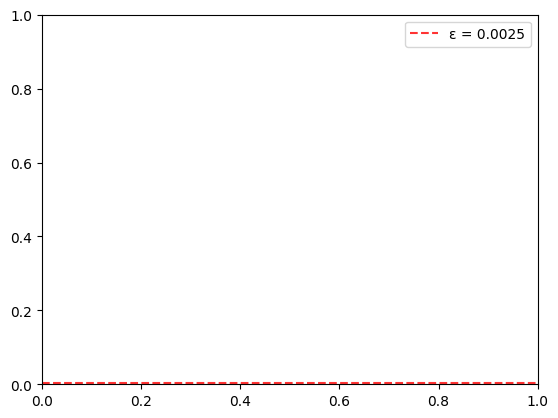

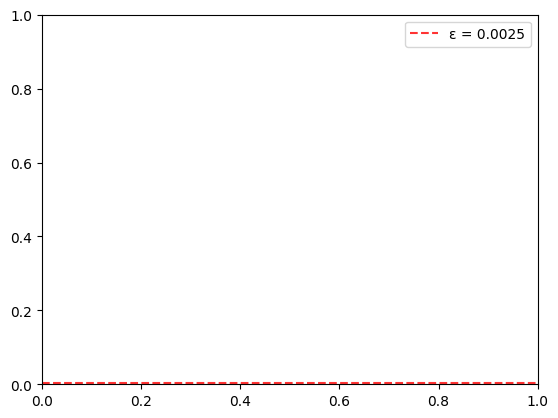

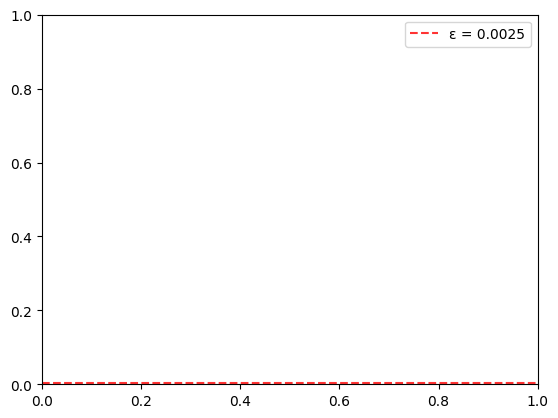

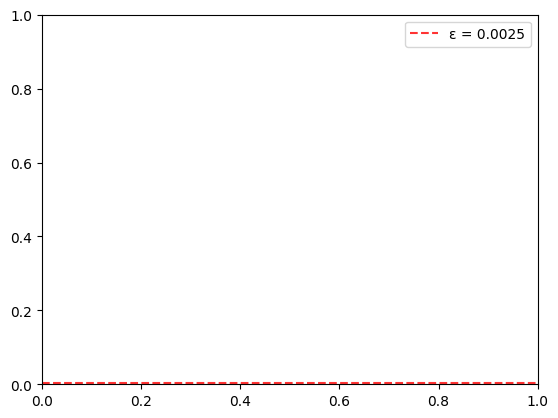

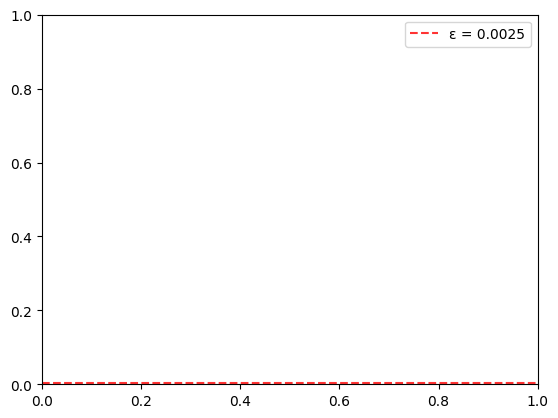

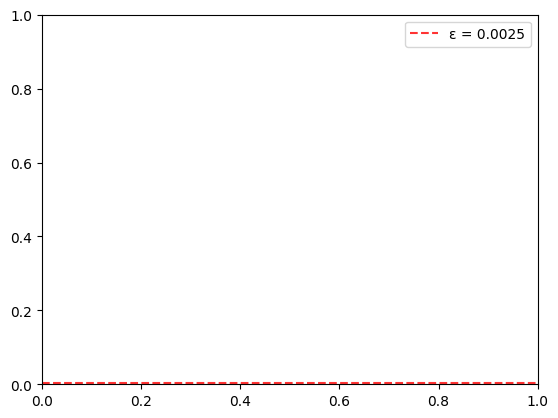

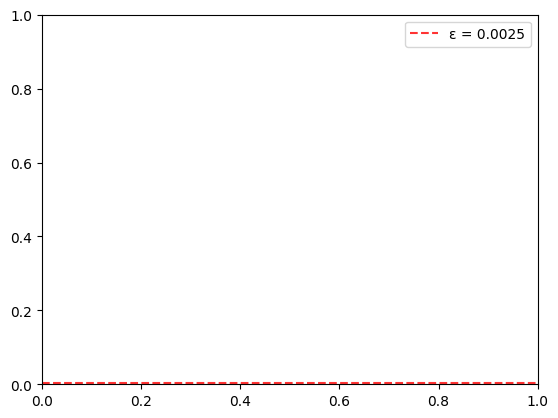

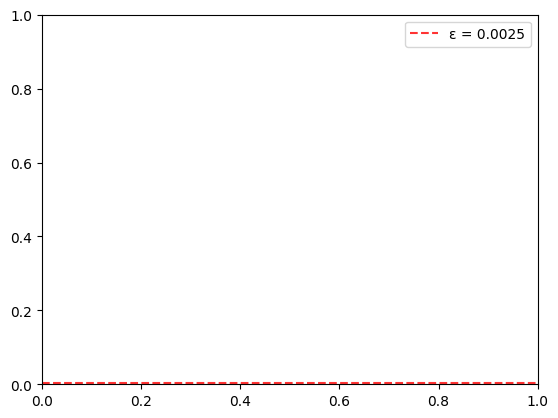

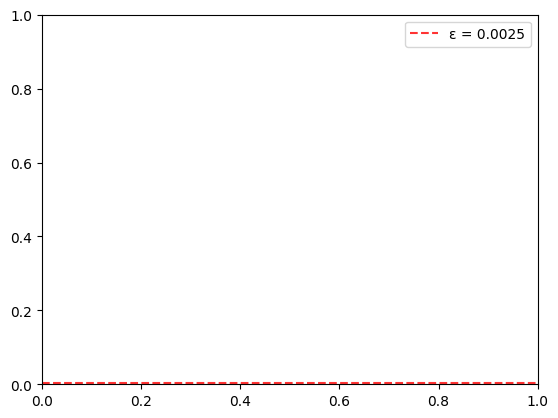

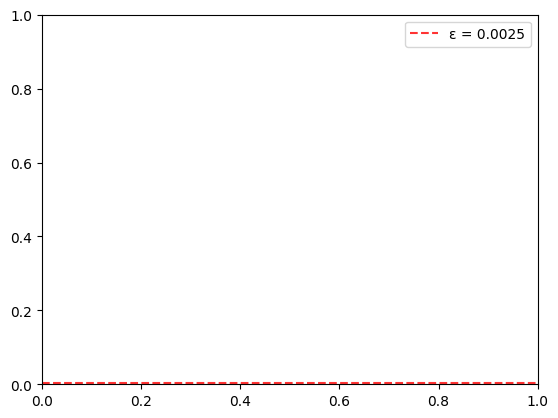

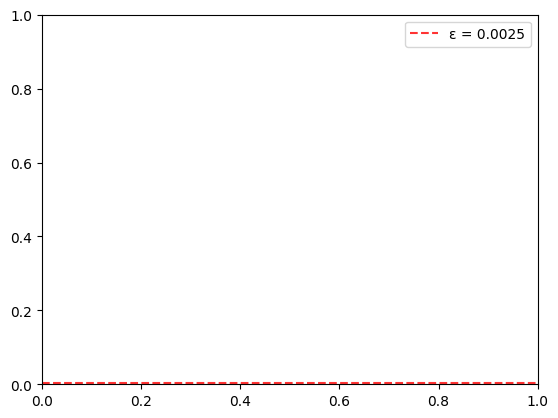

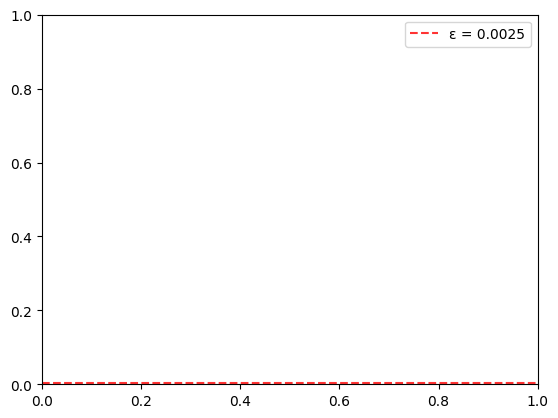

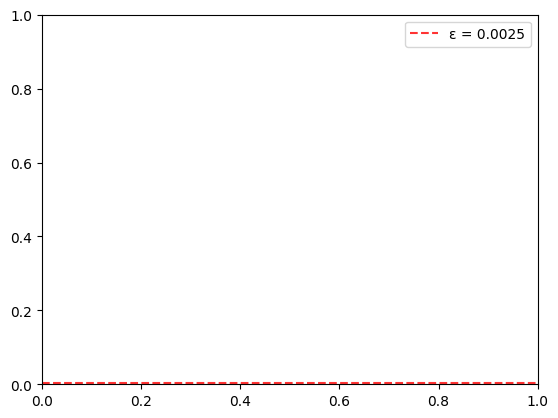

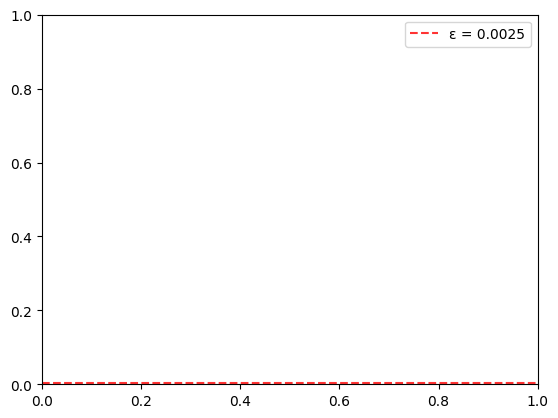

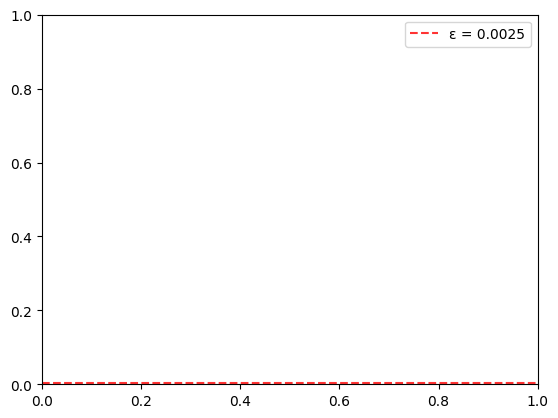

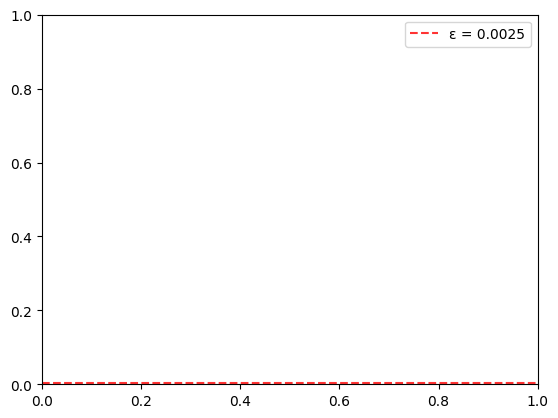

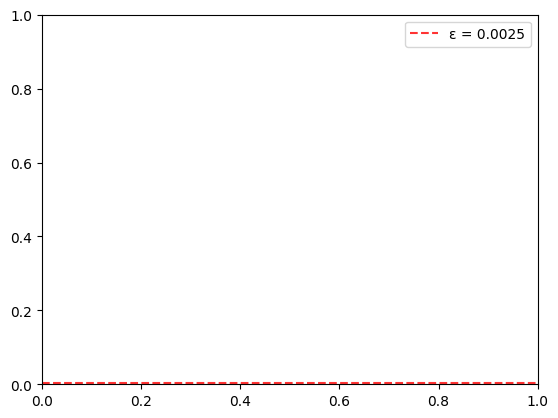

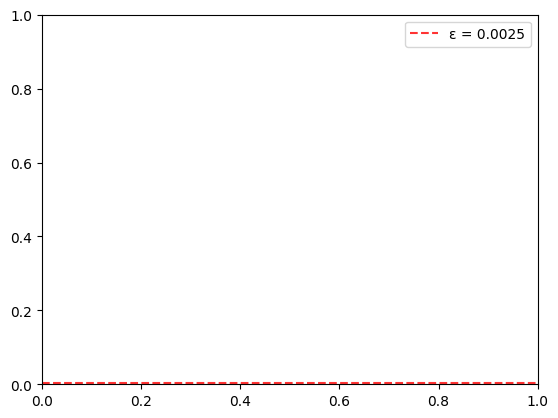

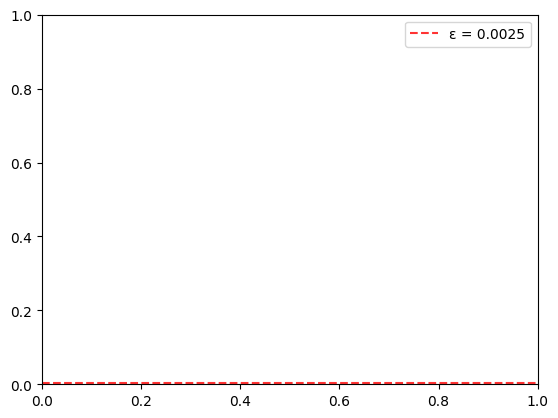

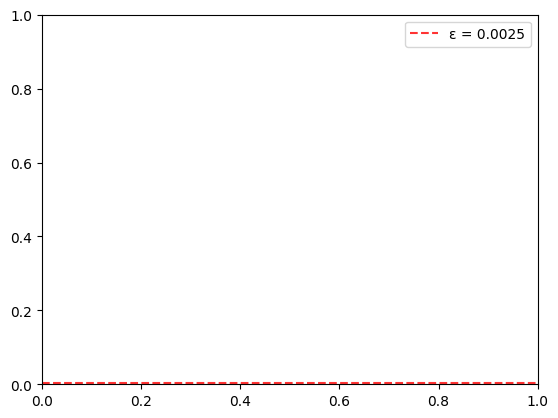

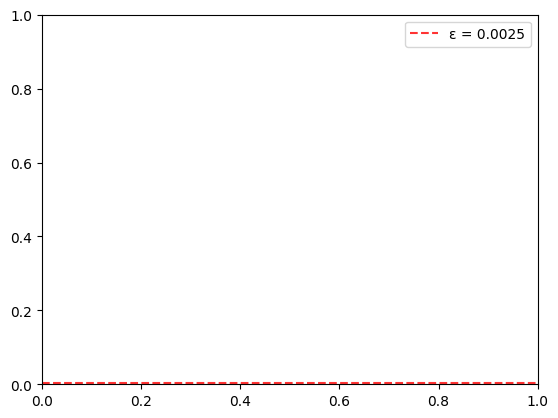

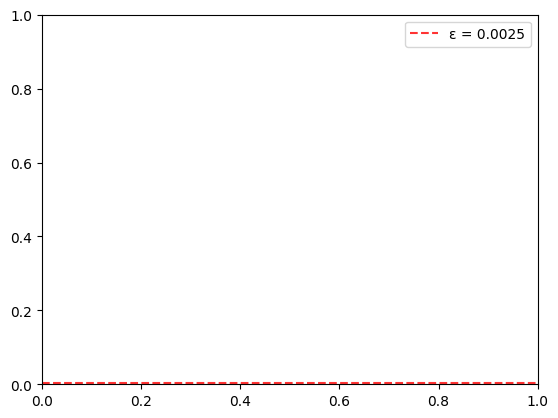

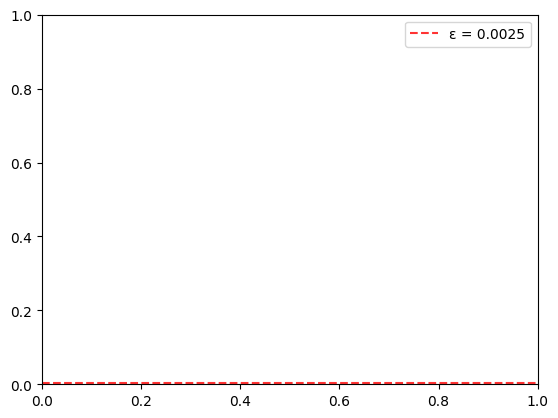

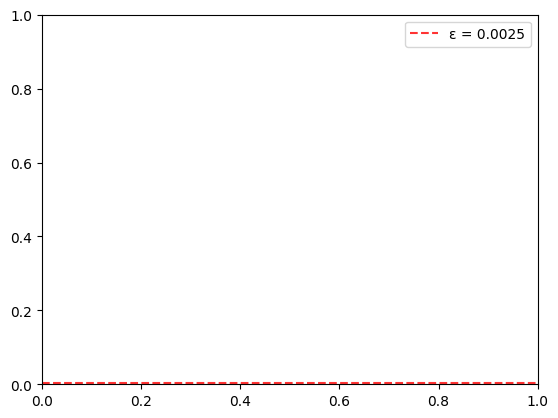

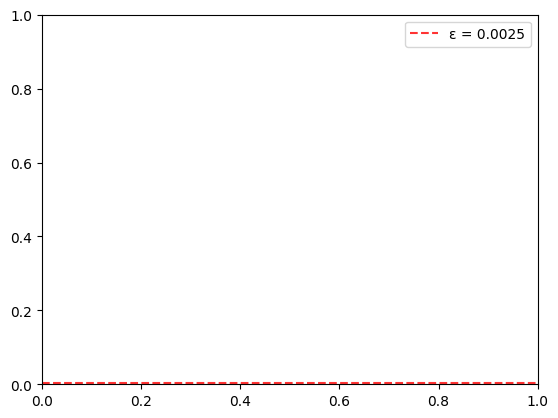

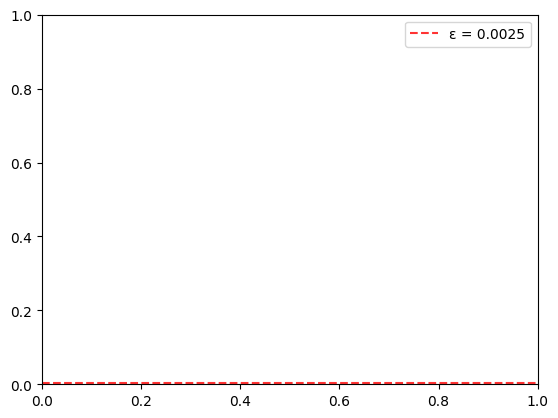

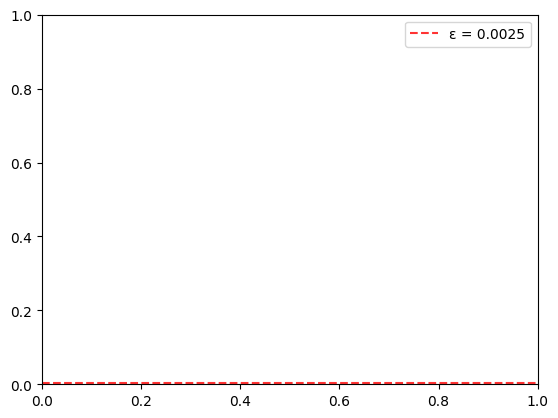

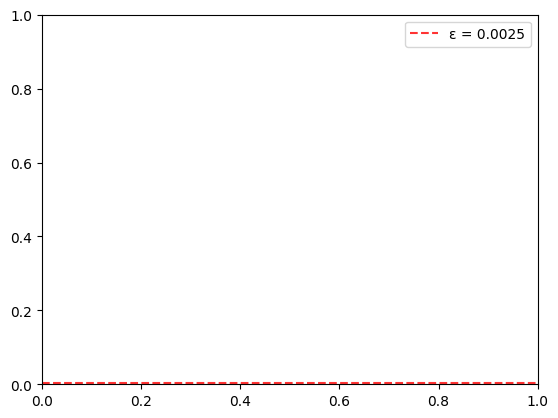

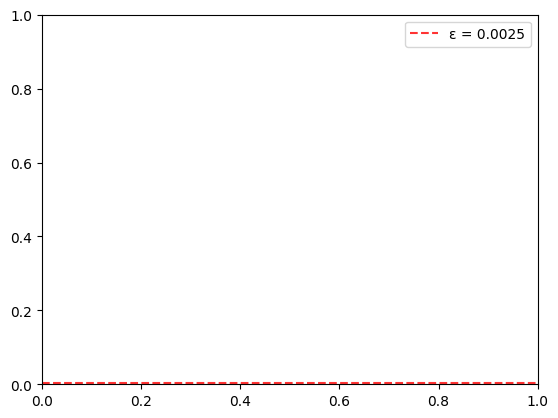

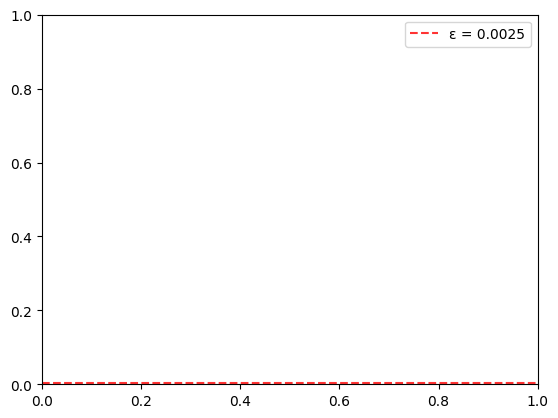

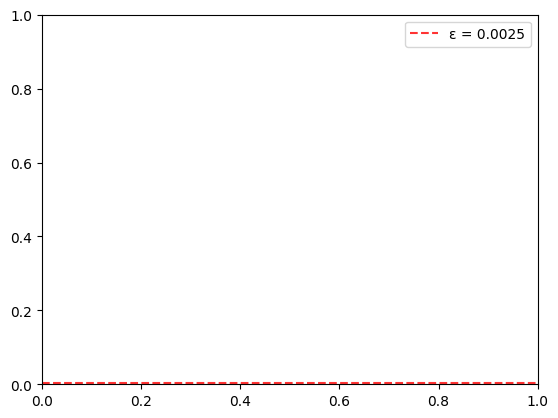

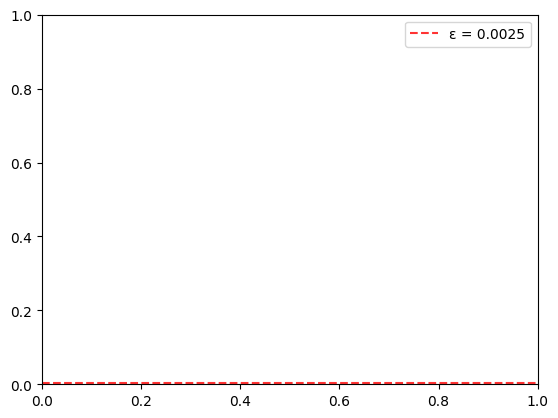

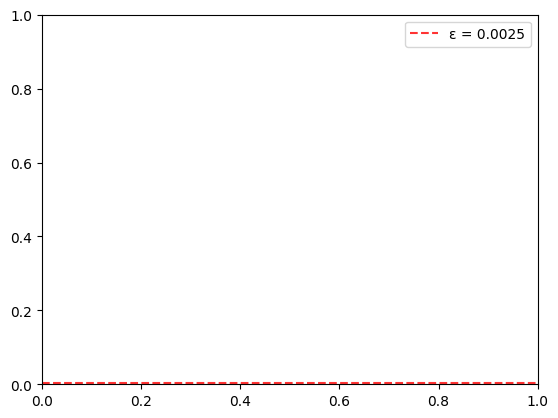

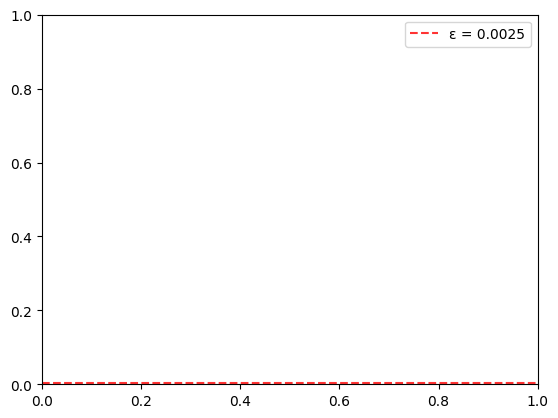

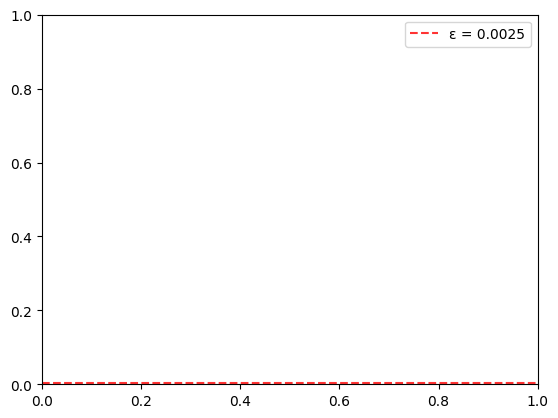

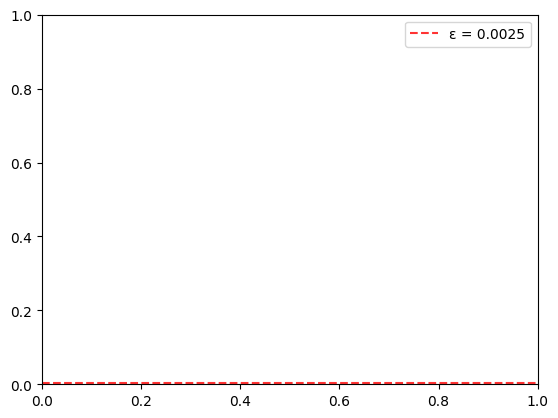

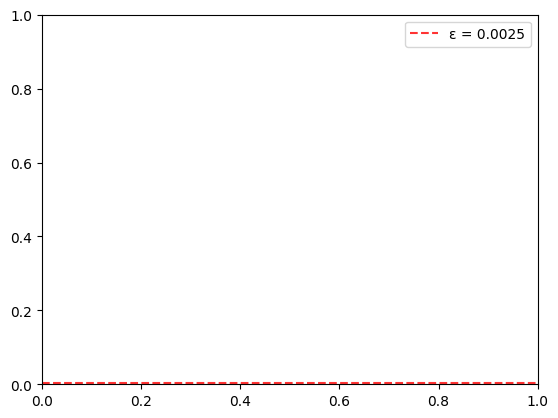

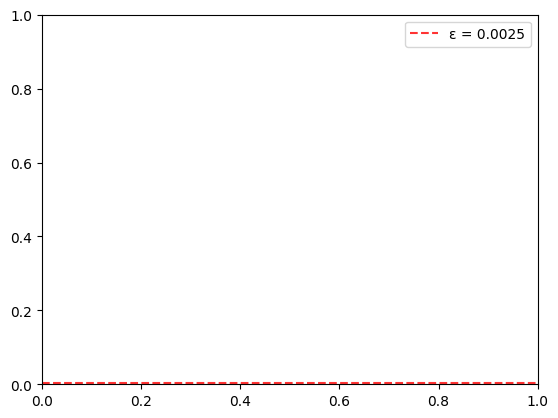

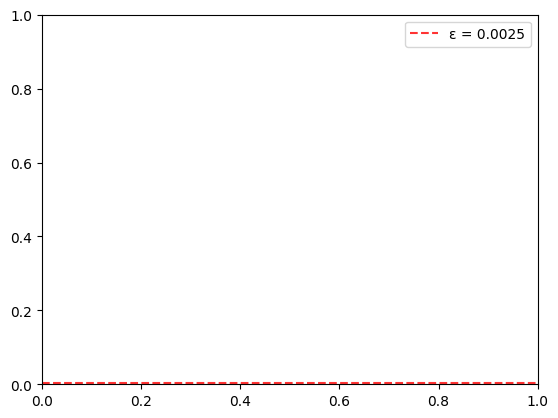

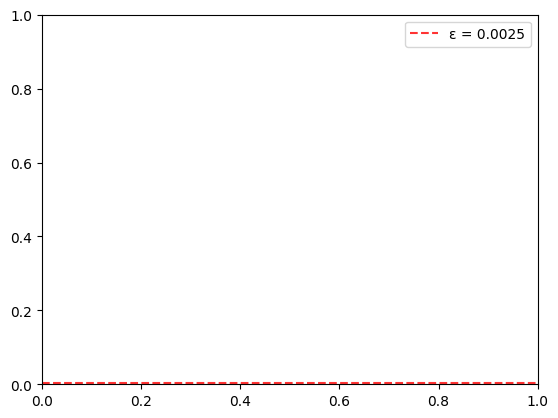

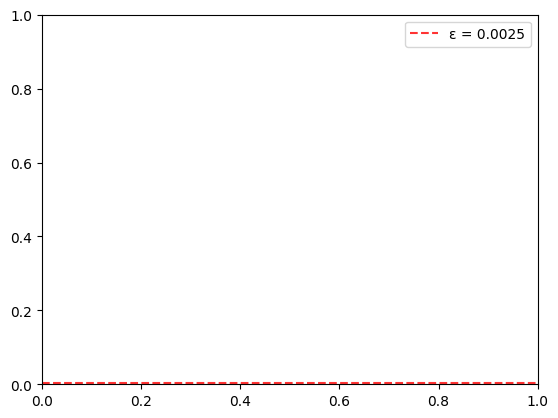

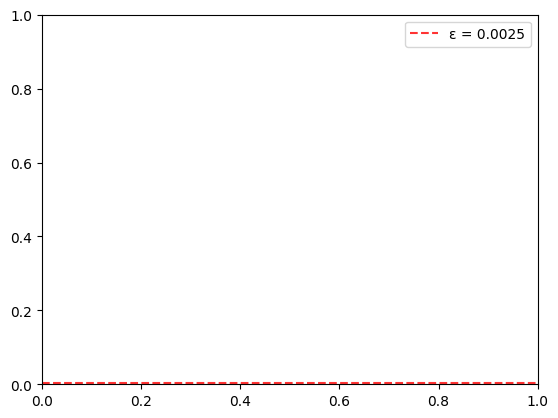

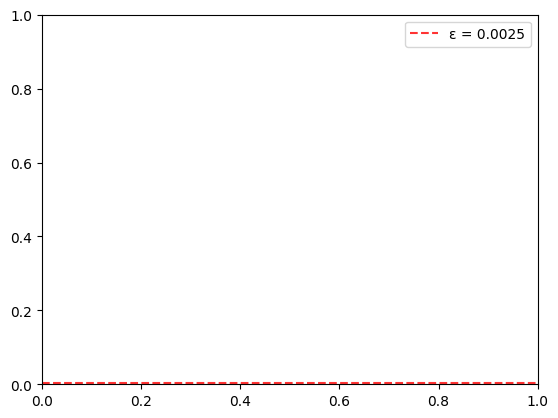

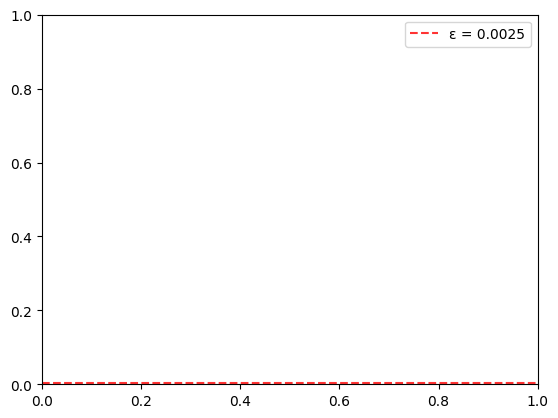

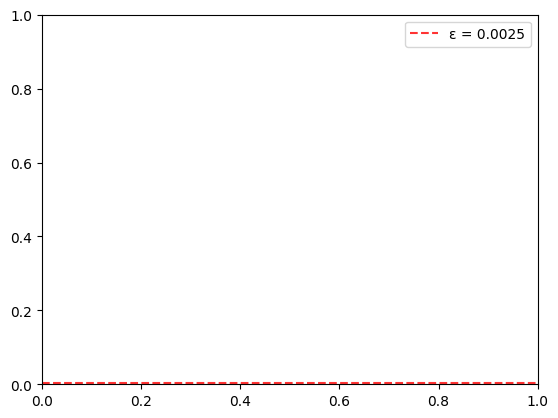

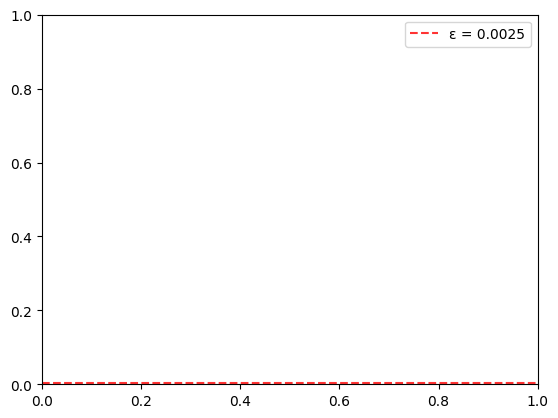

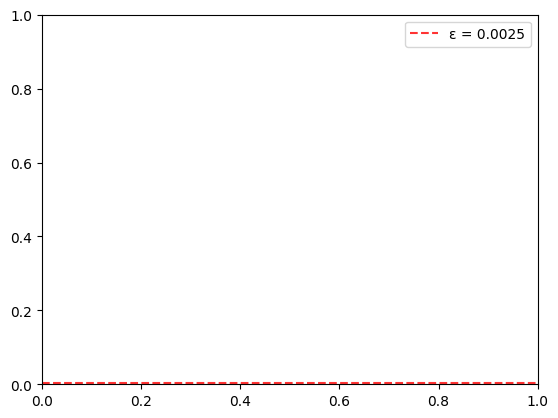

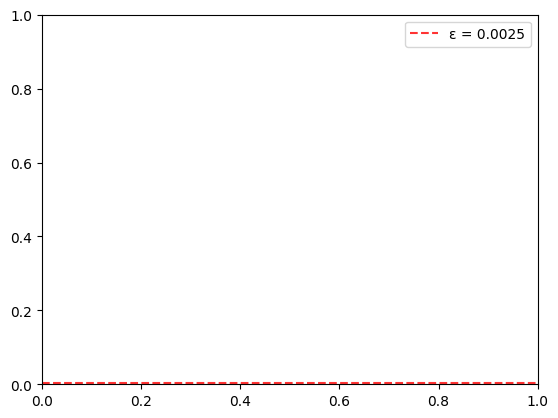

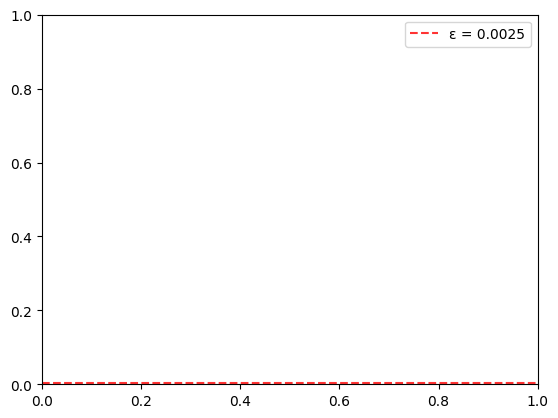

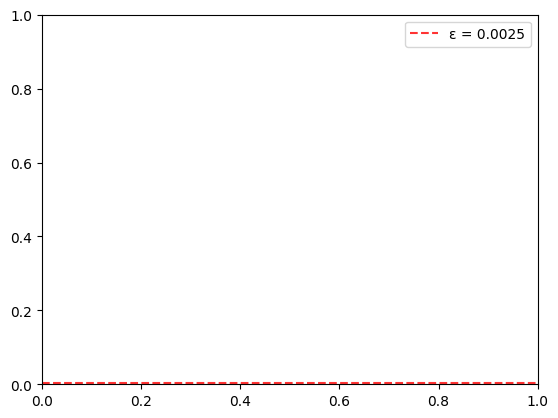

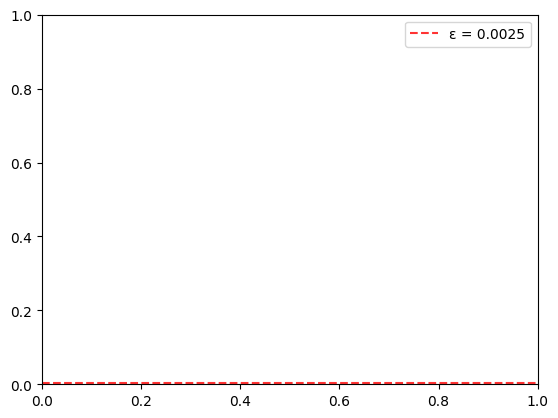

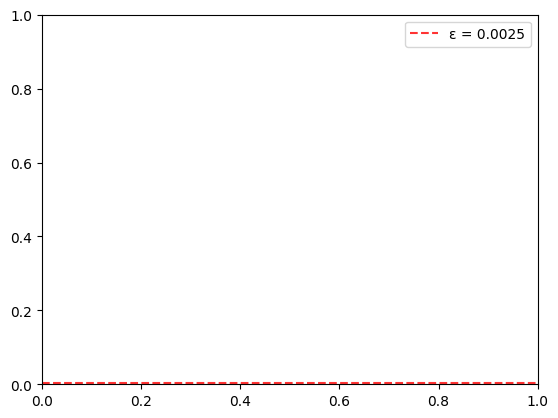

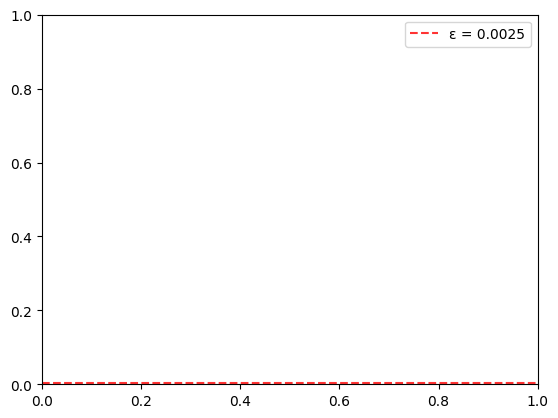

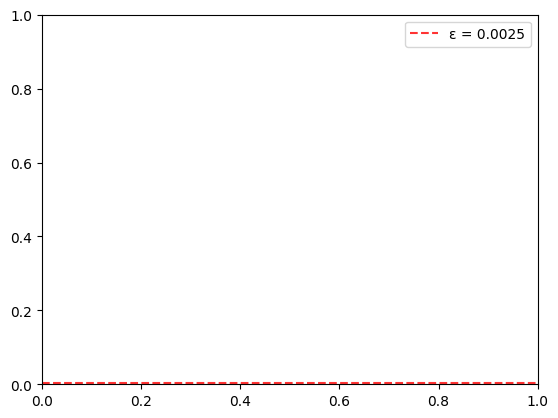

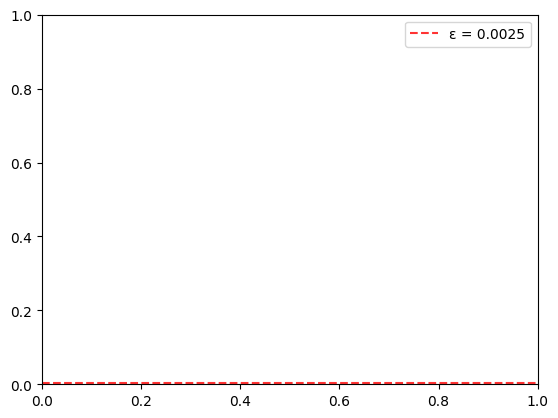

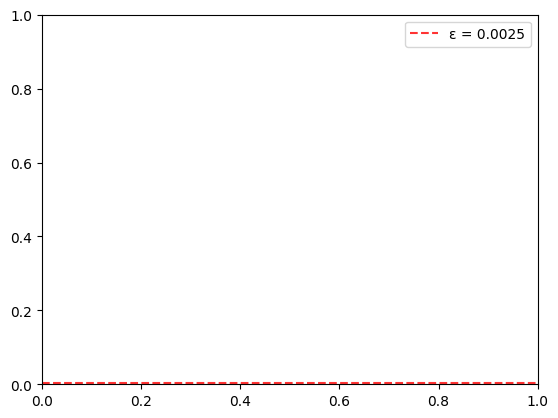

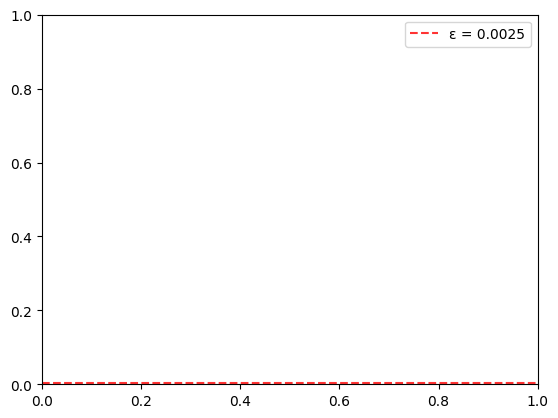

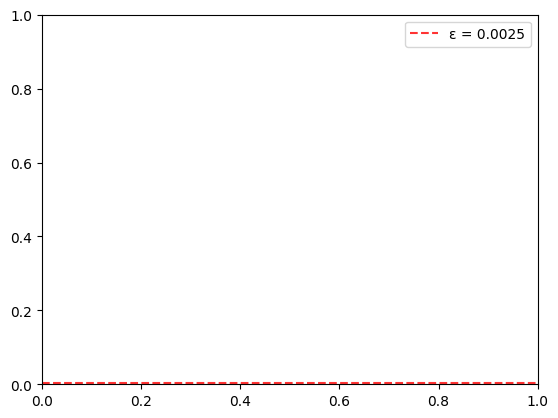

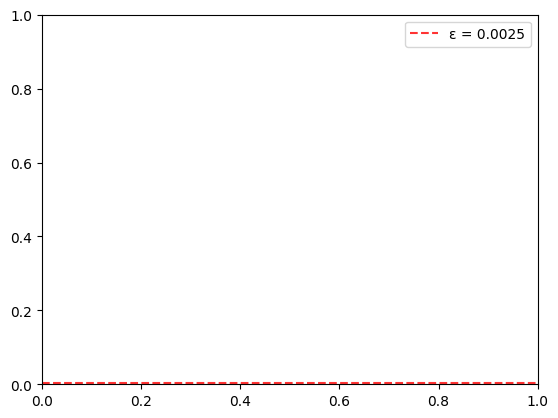

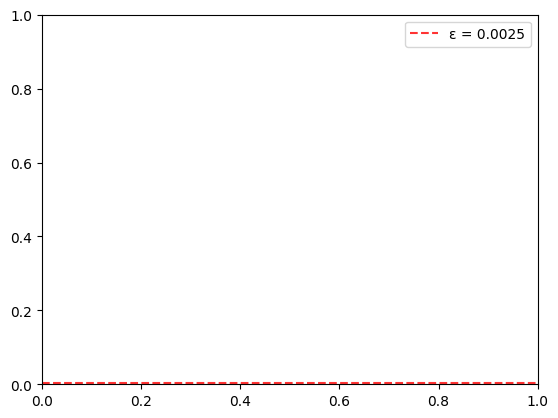

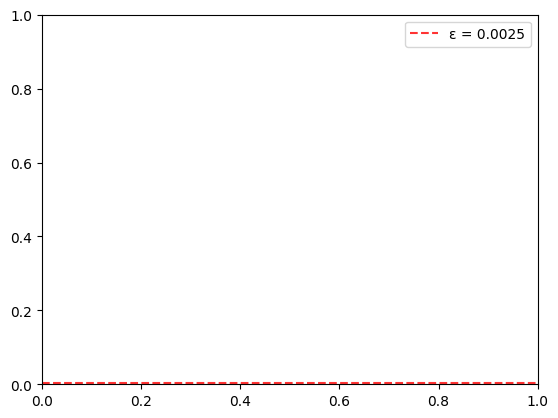

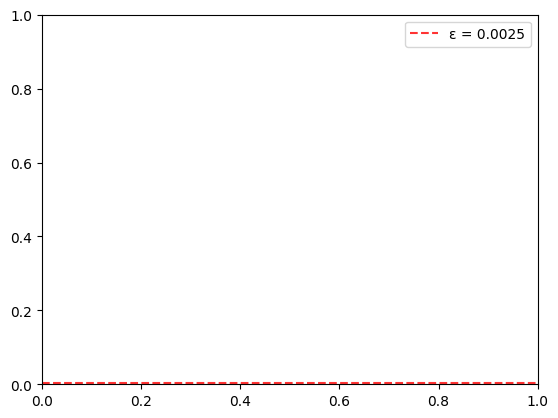

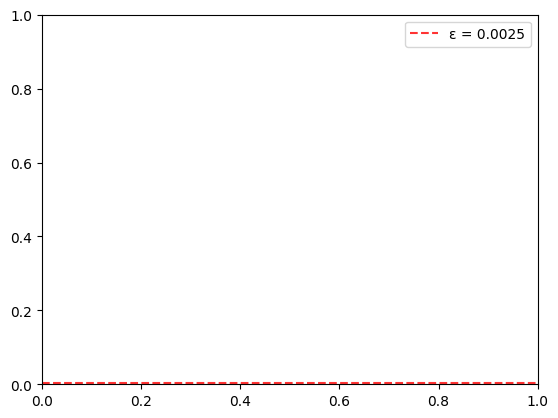

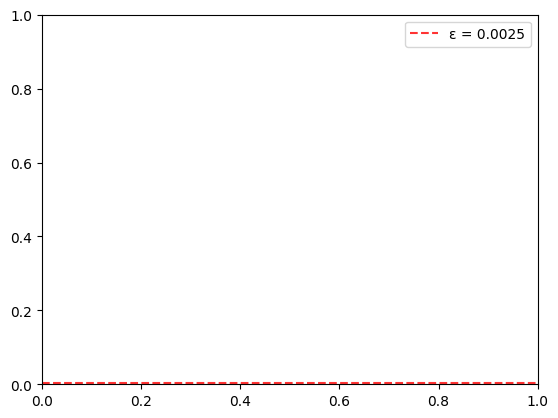

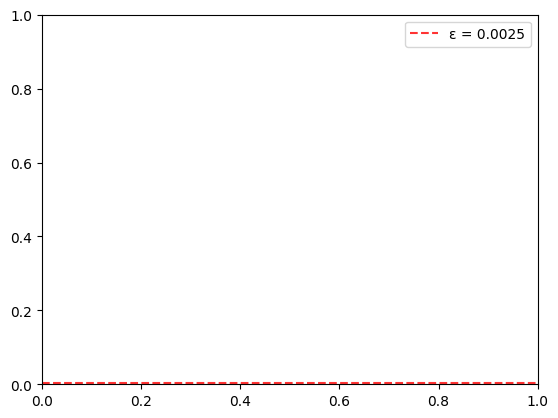

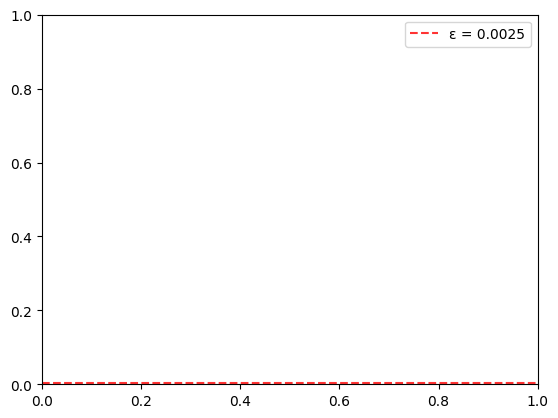

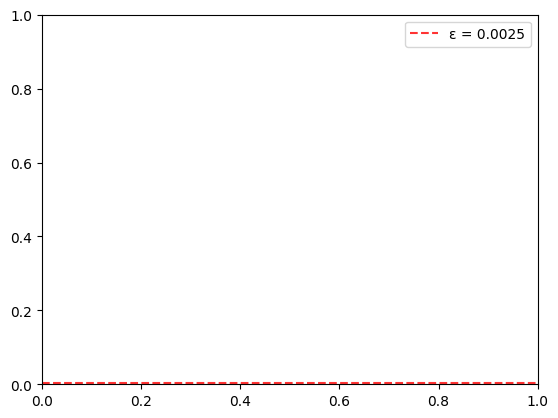

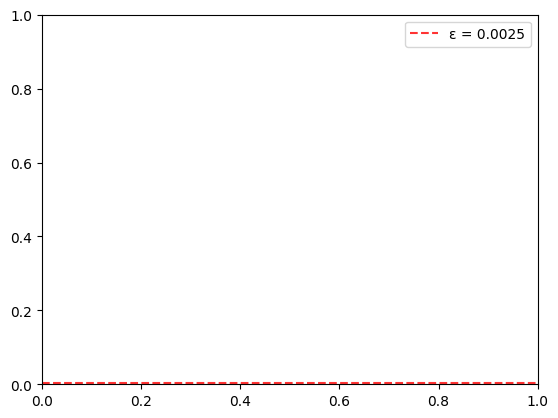

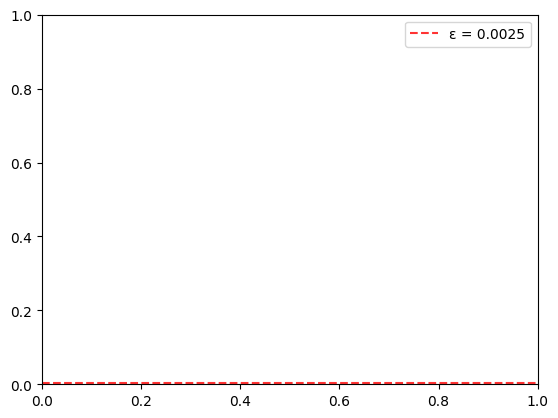

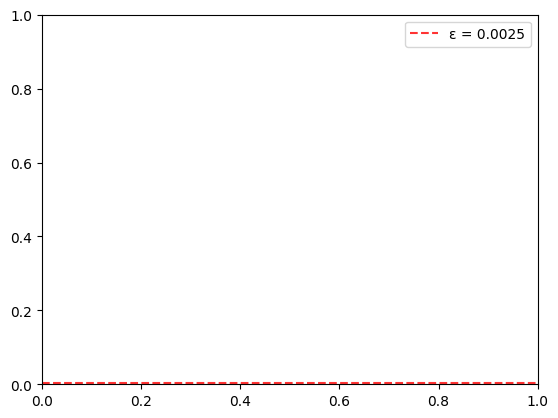

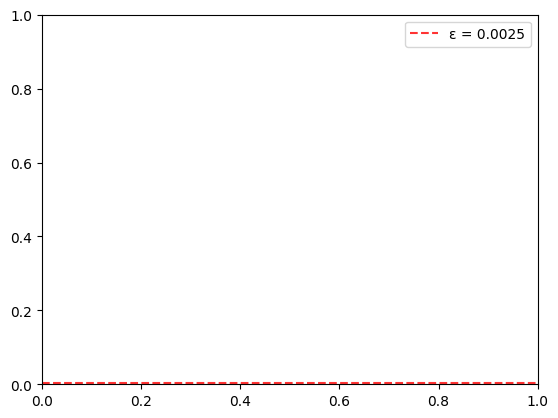

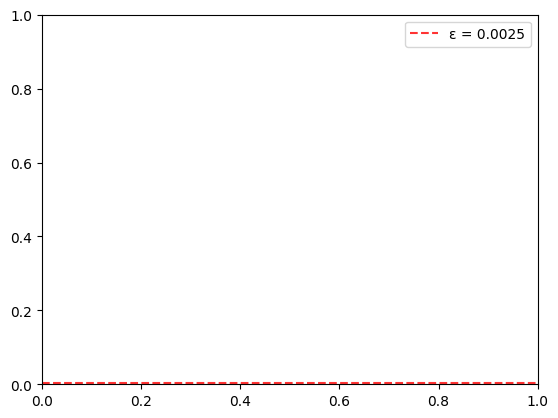

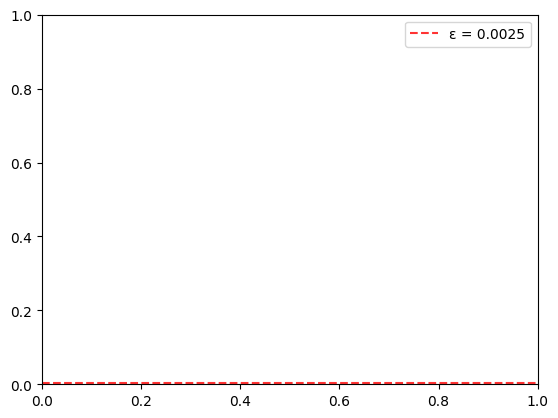

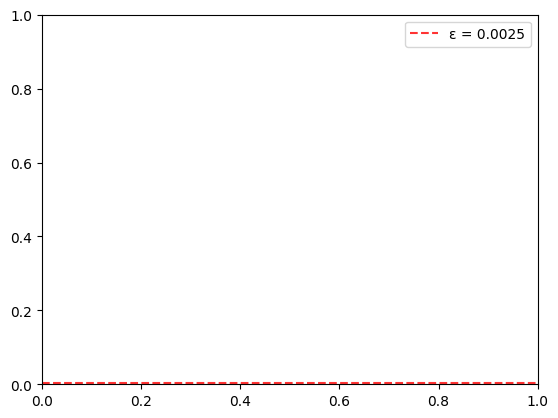

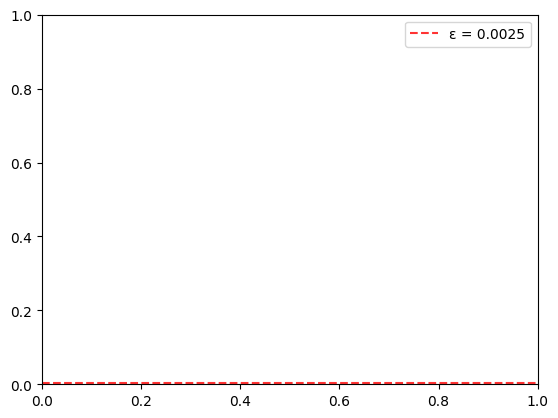

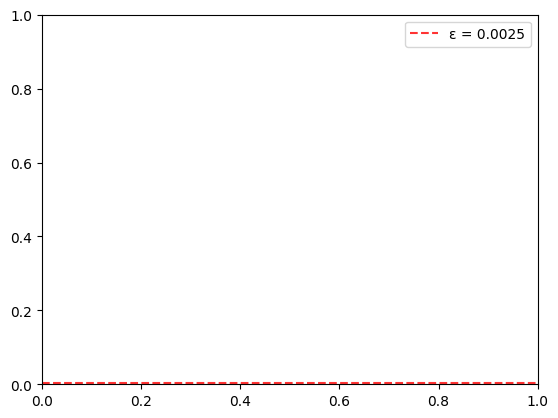

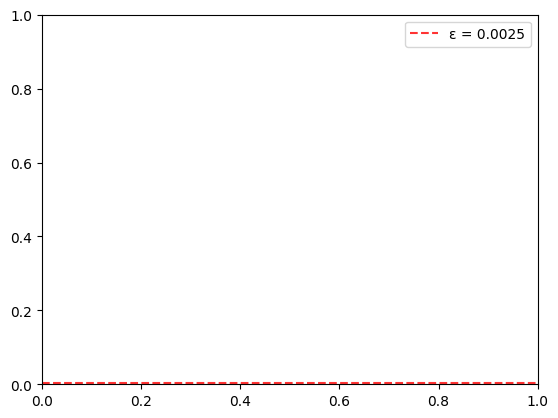

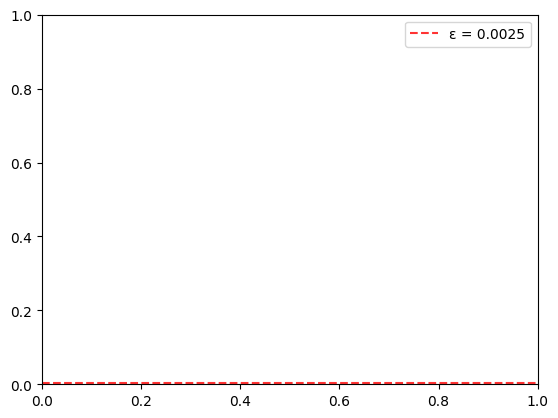

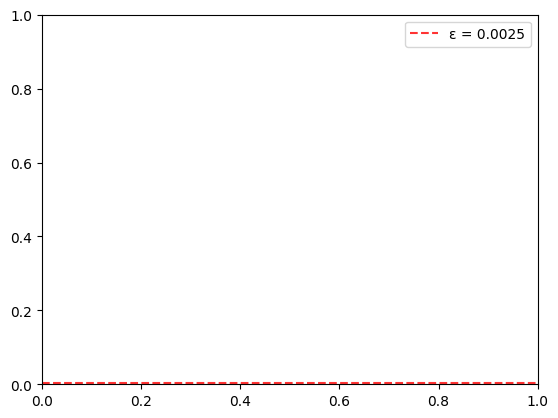

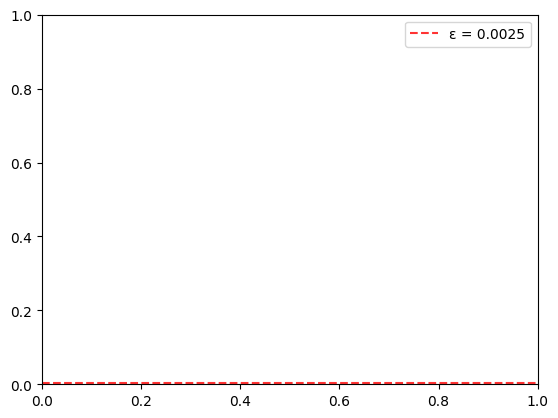

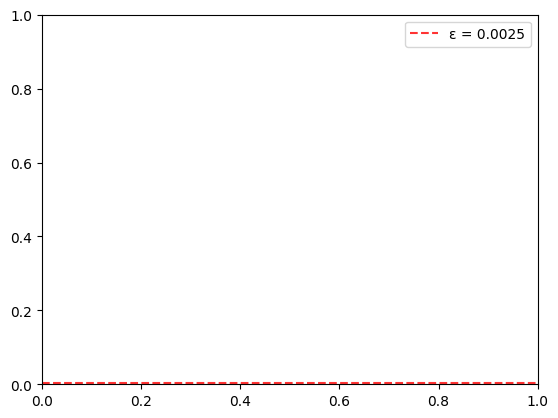

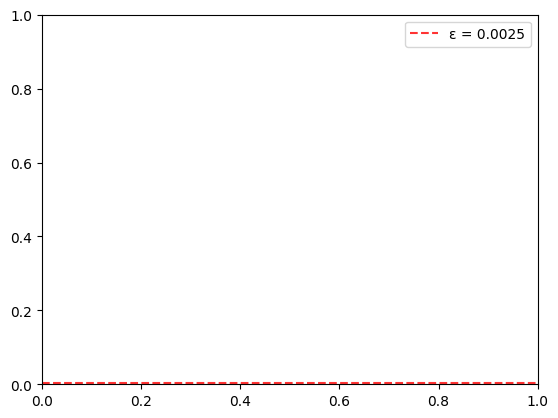

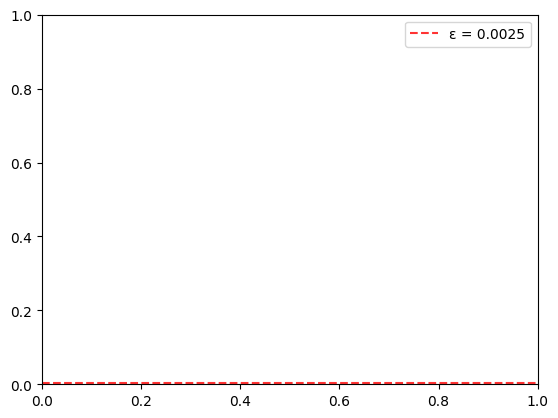

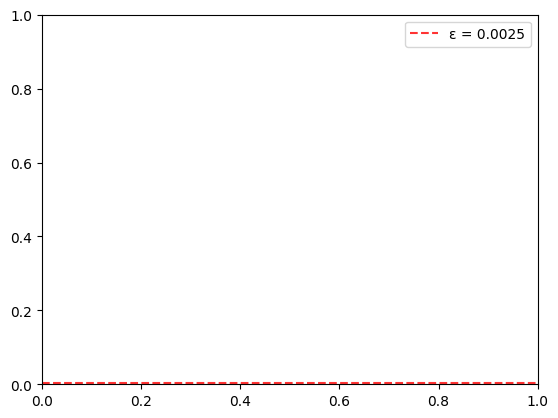

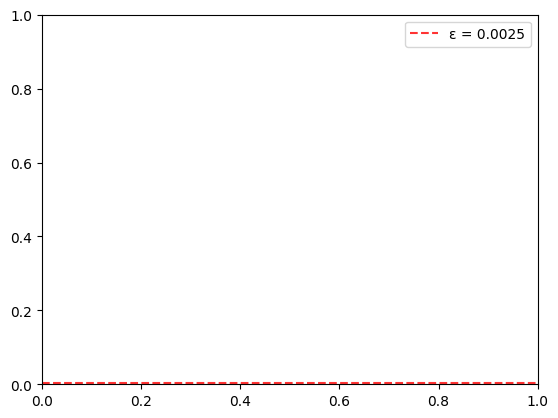

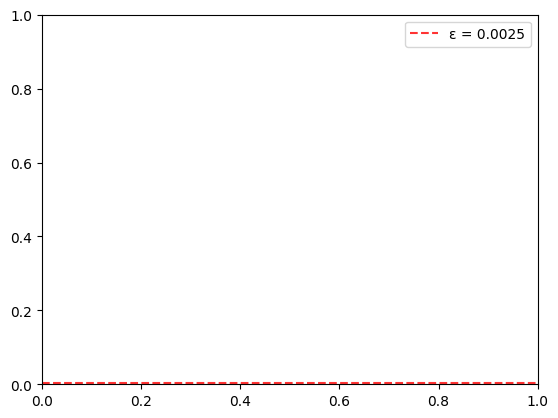

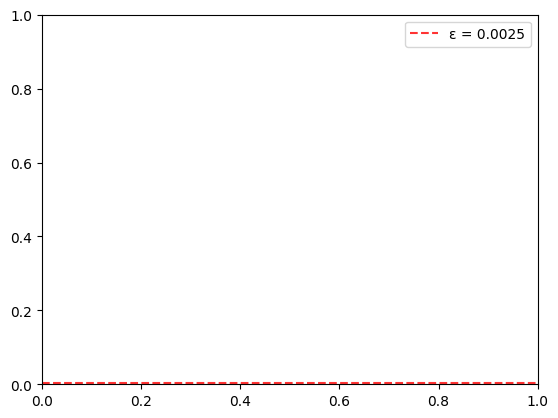

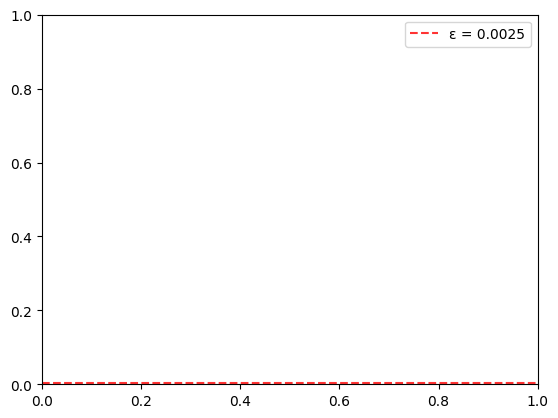

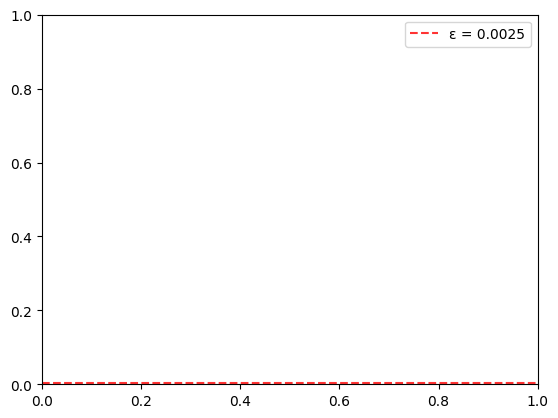

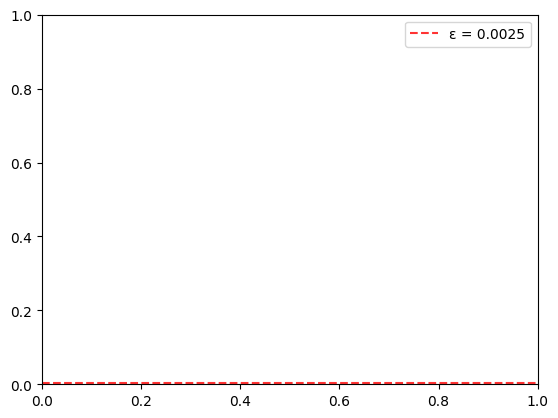

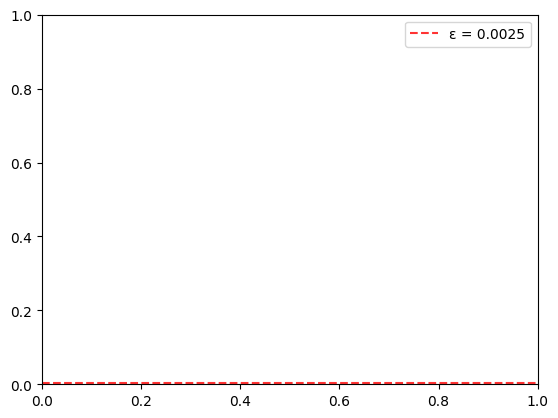

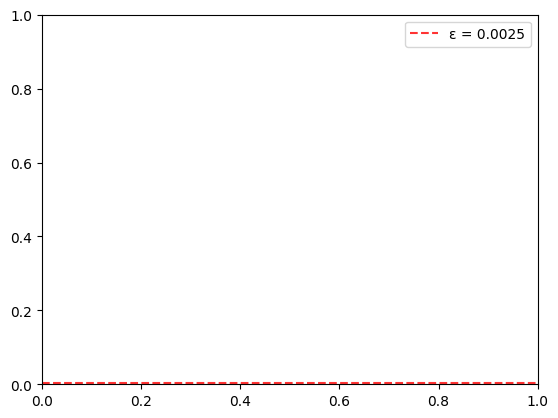

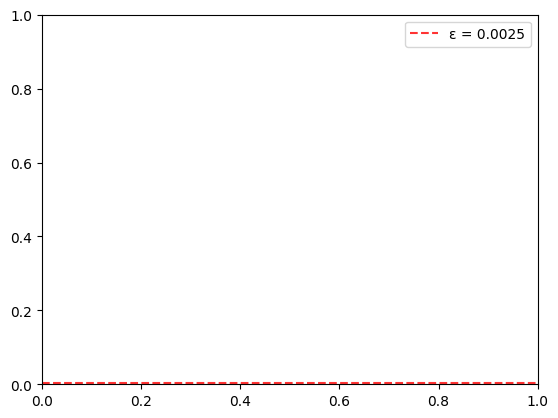

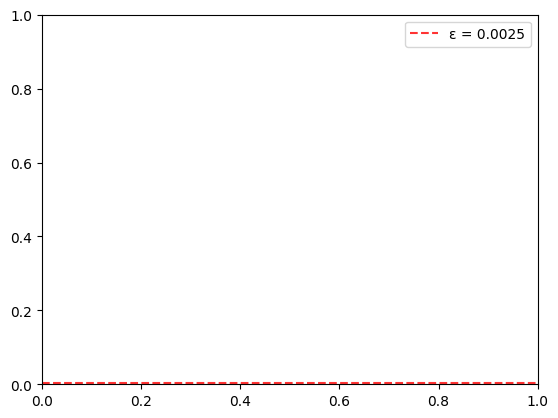

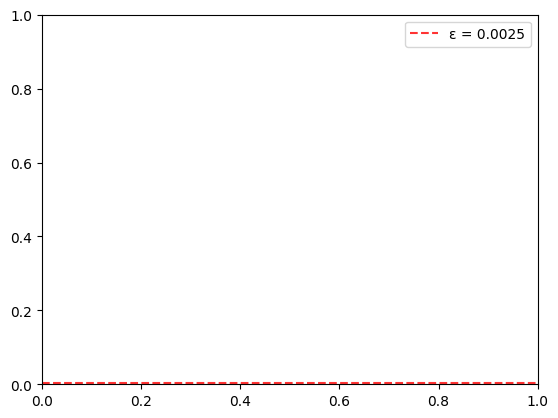

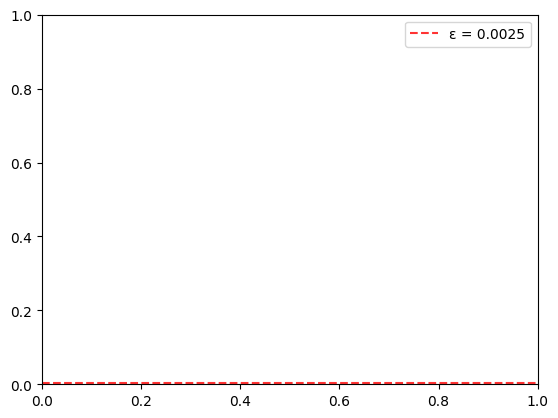

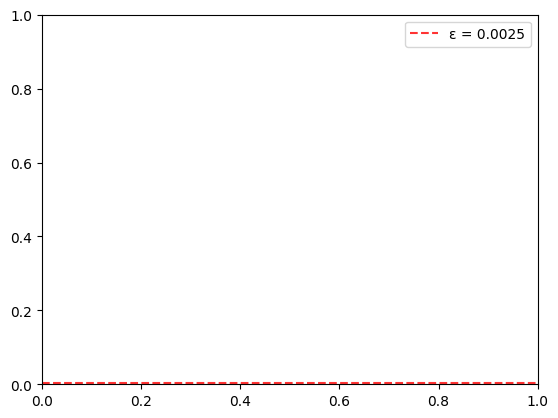

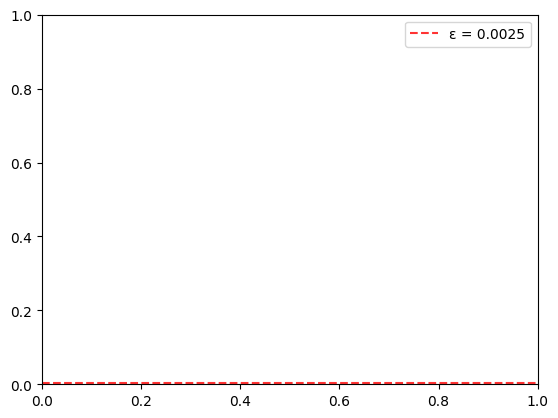

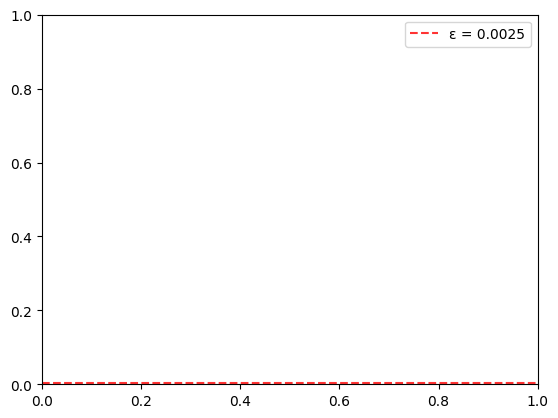

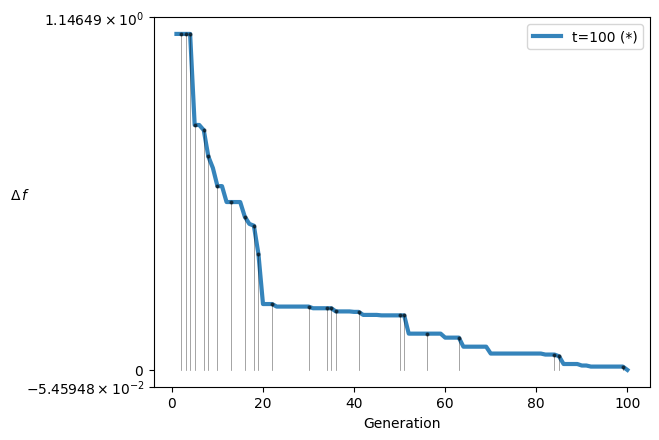

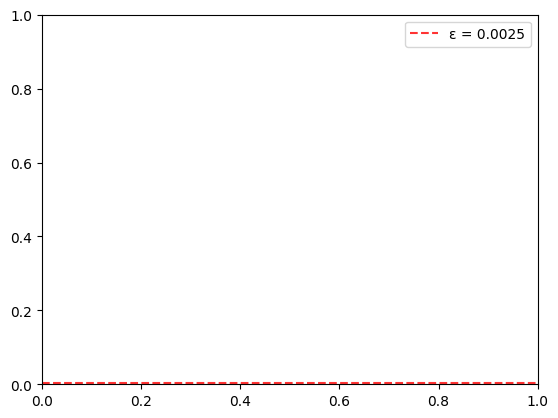

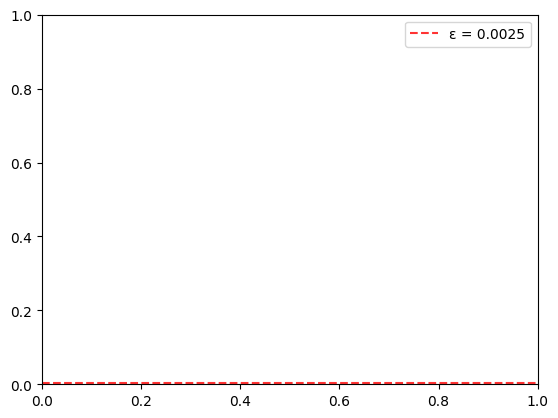

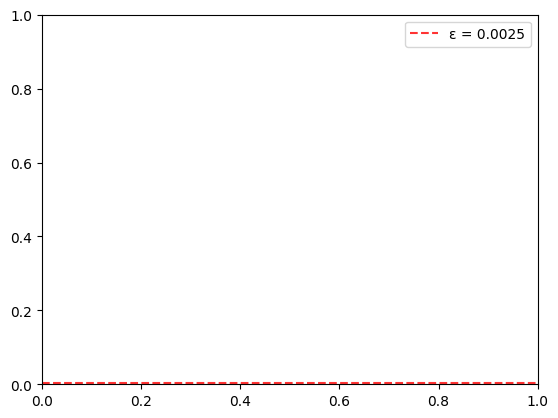

KeyboardInterrupt: 

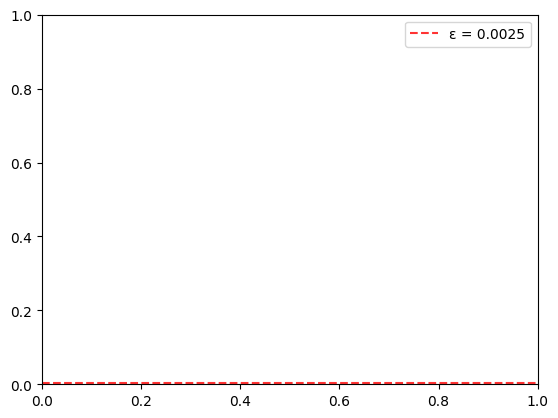

In [ ]:
from pymoo.util.running_metric import RunningMetricAnimation

running = RunningMetricAnimation(delta_gen=100,
                        n_plots=5,
                        key_press=False,
                        do_show=True)

for algorithm in res.history[:500]: 
    running.update(algorithm)

How to interpret the running metric graph - 

delta f is the "metric", which represents the distance of the current solution from the best solution. Each line represents 100 generations (```delta_gen```). The metric for each line is calculated assuming that the airfoil at the end of 100 generations is the "best". So, for the t=100 line, the airfoil at the 100th gen is the reference, for t=200 its the airfoil at gen=200, so on.

How do you actually assess convergence? A **downard trend** in a `t` line means that the optimizer is able to improve its solution. A **horizontal region** implies a stagnation, where the optimizer is not able to improve the solution. The algorithm is considered to be converged if the changes in the metric are less than 0.25% in the last `delta_gen` generations. Overlapping lines also mean that the optimizer is not able to make significant improvements.

Next, lets visualize the Design Space exploration. We'll use a Parallel Coordinates Plot since we have 11 params in the PARSEC parametrization. A simpler representation like the NACA would of course, make the plot less "crowded"

In [3]:

fig = px.parallel_coordinates(
    df, 
    color="Cl",  # Color lines by Efficiency
    labels={col: col for col in df.columns},
    color_continuous_scale=px.colors.sequential.Viridis,
    title="Overall Design Space exploration",
    template='plotly'
)
fig.show()

In the above graph, we see each *vertical "axes"* representing a *parameter from our airfoil parametrization* method, with the values at the bottom to top being their respective bounds. Note that the last 2 vertical axes are L/D and our airfoil operating window. *Each solution* is represented by a *horizontal line* and colored on the basis of L/D.

Click and drag on a vertical axis to create a filter region to see only those solutions that pass through the specified region. Double click on the axis to remove. You can also move move the vertical axes horizontally by clicking on the variable name and dragging them.

How to analyse - 
1) Clumped lines => An important and sensitive parameter and region for L/D. Sparse lines represent the opposite
    - If lines are spread throughout a vertical axes, it means that the output variable is not very sensitve to that design parameter. We can see the opposite of this statement with ```X_up, alpha_te, beta_te```. With ```X_up``` we see most lines pass through the bottom half, while for ```alpha_te and beta_te```, almost all lines are near the lowest bounds. This implies that these regions in these design variables exert a strong influence on the output L/D 
2) If lines between vertical axes cross each other, that represents an inverse relationship. Ex: Look at `r_le` and `X_up`. High `r_le` with low `X_up` leads to high L/D, while low `r_le` with high `X_up` leads to low L/D

Pareto Front:

In [4]:
fig = px.scatter(df,
                 x='Window',
                 y='Cl',
                 title='Pareto Front of Cl vs Operational Window',
                 template='plotly',
                 width=800,
                 height=600
                 )

fig.update_traces(
    marker=dict(
        size=10,
        color='blue',
        line=dict(
            width=2,
            color='black'
        )
    )
)

fig.show()

Plot airfoil of selected point from Pareto Front

In [ ]:
# Get params for desired pareto foil, write its dat and polar file
# Construct pareto front data
pareto_front = []
for i in range(len(X)):
    pareto_front.append((real_Cl[i], real_Win[i]))

# The right most airfoil is index 0
desired_foil = 4

# Construct input params
input_array = np.array([])
for i in range(0, len(X[desired_foil])):
    input_array = np.append(input_array, X[desired_foil][i])
 
if AIRFOIL_PARAMETRIZATION_MODE == "NACA":
    naca_code = input_array.astype(int)
    pareto_airfoil = Airfoil(name=f"pareto_foil_{desired_foil}", pid=999,
                  nacaCode=naca_code)
else:
    params = parsecParams.from_array(input_array)
    pareto_airfoil = Airfoil(name=f"pareto_foil_{desired_foil}", pid=999,
                  params=params)

# Load airfoil
dat_file_name = f"pareto_Front_foil{desired_foil}.dat"
output_path = Path(f"postProcess_data/{dat_file_name}")


if AIRFOIL_PARAMETRIZATION_MODE == "PARSEC":
    # Write dat and move polar file to postProcess_data
    pareto_airfoil.write_dat_file(out_path=output_path)
    pareto_airfoil.xfoil_analysis(mode="PARSEC", Re=250000, alpha_sequence=[0, 20, 1])
    polar_output_path = Path(f"postProcess_data/pareto_Front_foil{desired_foil}_Polar.txt")
    shutil.copy(pareto_airfoil.polar_file, polar_output_path)
    pareto_airfoil.cleanup()
else:
    pareto_airfoil.write_dat_file(out_path=output_path, naca_code=naca_code)
    pareto_airfoil.xfoil_analysis(mode="NACA", Re=250000, alpha_sequence=[0, 20, 1])
    polar_output_path = Path(f"postProcess_data/pareto_Front_foil{desired_foil}_Polar.txt")
    shutil.copy(pareto_airfoil.polar_file, polar_output_path)
    pareto_airfoil.cleanup()

In [18]:
# Load and plot both baseline and pareto airfoil shapes
baseline_dat = np.genfromtxt("postProcess_data/baseline.dat", skip_header=1)
pareto_dat = np.genfromtxt(f"postProcess_data/pareto_Front_foil{desired_foil}.dat", skip_header=1)

baseline_x = baseline_dat[:, 0]
baseline_y = baseline_dat[:, 1]
pareto_x = pareto_dat[:, 0]
pareto_y = pareto_dat[:, 1]

fig = go.Figure()

# Add baseline airfoil
fig.add_trace(go.Scatter(x=baseline_x, y=baseline_y, mode='lines', 
                         name='Baseline', line=dict(color='blue', width=2)))

# Add pareto airfoil
fig.add_trace(go.Scatter(x=pareto_x, y=pareto_y, mode='lines', 
                         name=f'Pareto Foil #{desired_foil}', line=dict(color='red', width=2)))

fig.update_layout(title='Airfoil Comparison: Baseline vs Optimized',
                  xaxis_title='x/c',
                  yaxis_title='y/c',
                  template='plotly',
                  hovermode='closest')

fig.show()

In [13]:
print(X[desired_foil])

[  0.05389852   0.4125704    0.17448135  -0.92         0.64930457
   0.10073867  -1.0409358    0.           0.         -29.93618068
   2.27826332]


In [19]:
# Load polar data for baseline and pareto foil
baseline_polar = np.genfromtxt("postProcess_data/baseline_Polar.txt", skip_header=12)
pareto_polar = np.genfromtxt(f"postProcess_data/pareto_Front_foil{desired_foil}_Polar.txt", skip_header=12)

# If either polar is empty, inform the user
if baseline_polar.size == 0:
    raise RuntimeError("Baseline polar file is empty or missing")
if pareto_polar.size == 0:
    raise RuntimeError("Pareto polar file is empty or missing")

baseline_aoa = baseline_polar[:, 0]
baseline_cl = baseline_polar[:, 1]
baseline_cd = baseline_polar[:, 2]
baseline_ld = baseline_cl / baseline_cd

pareto_aoa = pareto_polar[:, 0]
pareto_cl = pareto_polar[:, 1]
pareto_cd = pareto_polar[:, 2]
pareto_ld = pareto_cl / pareto_cd

# Create subplots: 2x2 grid
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Cl vs AoA", "Cd vs AoA", "Cl/Cd vs AoA", "Cl vs Cd")
)

# Cl vs AoA
fig.add_trace(go.Scatter(x=baseline_aoa, y=baseline_cl, mode='lines', name='Baseline', 
                         line=dict(color='blue', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=pareto_aoa, y=pareto_cl, mode='lines', name='Pareto', 
                         line=dict(color='red', width=2)), row=1, col=1)

# Cd vs AoA
fig.add_trace(go.Scatter(x=baseline_aoa, y=baseline_cd, mode='lines', name='Baseline', 
                         line=dict(color='blue', width=2), showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=pareto_aoa, y=pareto_cd, mode='lines', name='Pareto', 
                         line=dict(color='red', width=2), showlegend=False), row=1, col=2)

# Cl/Cd vs AoA
fig.add_trace(go.Scatter(x=baseline_aoa, y=baseline_ld, mode='lines', name='Baseline', 
                         line=dict(color='blue', width=2), showlegend=False), row=2, col=1)
fig.add_trace(go.Scatter(x=pareto_aoa, y=pareto_ld, mode='lines', name='Pareto', 
                         line=dict(color='red', width=2), showlegend=False), row=2, col=1)

# Cl vs Cd
fig.add_trace(go.Scatter(x=baseline_cd, y=baseline_cl, mode='lines', name='Baseline', 
                         line=dict(color='blue', width=2), showlegend=False), row=2, col=2)
fig.add_trace(go.Scatter(x=pareto_cd, y=pareto_cl, mode='lines', name='Pareto', 
                         line=dict(color='red', width=2), showlegend=False), row=2, col=2)

# Update axes labels
fig.update_xaxes(title_text="AoA (deg)", row=1, col=1)
fig.update_yaxes(title_text="Cl", row=1, col=1)

fig.update_xaxes(title_text="AoA (deg)", row=1, col=2)
fig.update_yaxes(title_text="Cd", row=1, col=2)

fig.update_xaxes(title_text="AoA (deg)", row=2, col=1)
fig.update_yaxes(title_text="L/D", row=2, col=1)

fig.update_xaxes(title_text="Cd", row=2, col=2)
fig.update_yaxes(title_text="Cl", row=2, col=2)

fig.update_layout(title_text=f"Aerodynamic Polar Comparison: Baseline vs Pareto Foil #{desired_foil}",
                  template='plotly',
                  height=800,
                  width=1200,
                  hovermode='closest')

fig.show()